In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
df = pd.read_csv("car_prices.csv")

In [11]:
#Exploratory Data Analysis

print(df.head())           
print(df.info())           
print(df.describe())     
print(df.isnull().sum())   

   year   make                model        trim   body transmission  \
0  2015    Kia              Sorento          LX    SUV    automatic   
1  2015    Kia              Sorento          LX    SUV    automatic   
2  2014    BMW             3 Series  328i SULEV  Sedan    automatic   
3  2015  Volvo                  S60          T5  Sedan    automatic   
4  2014    BMW  6 Series Gran Coupe        650i  Sedan    automatic   

                 vin state  condition  odometer  color interior  \
0  5xyktca69fg566472    ca        5.0   16639.0  white    black   
1  5xyktca69fg561319    ca        5.0    9393.0  white    beige   
2  wba3c1c51ek116351    ca       45.0    1331.0   gray    black   
3  yv1612tb4f1310987    ca       41.0   14282.0  white    black   
4  wba6b2c57ed129731    ca       43.0    2641.0   gray    black   

                                   seller      mmr  sellingprice  \
0                 kia motors america  inc  20500.0       21500.0   
1                 kia motors ameri

In [12]:
# Price stats
prices = df['sellingprice'].values
print("Mean Price:", np.mean(prices))
print("Std Dev Price:", np.std(prices))

# Mileage stats
mileages = df['mmr'].values
print("Max Mileage:", np.max(mileages))
print("Min Mileage:", np.min(mileages))

# Normalize mileage
norm_mileage = (mileages - mileages.min()) / (mileages.max() - mileages.min())
print("Normalized Mileage (first 5):", norm_mileage[:5])

Mean Price: nan
Std Dev Price: nan
Max Mileage: nan
Min Mileage: nan
Normalized Mileage (first 5): [nan nan nan nan nan]


In [13]:
# Correlation between price and mileage
corr = np.corrcoef(prices, mileages)
print("Correlation Matrix:\n", corr)

# Random price samples
print("Random Prices:", np.random.choice(prices, size=5, replace=False))

Correlation Matrix:
 [[nan nan]
 [nan nan]]
Random Prices: [20750.  1800. 12750.  1100.  7500.]


In [14]:
percentiles = np.percentile(prices, [25, 50, 75])
print("Price Percentiles (25th, 50th, 75th):", percentiles)

# Cars above 75th percentile
high_price = df[df['sellingprice'] > percentiles[2]]
print(high_price[['make', 'model', 'sellingprice']].head())

Price Percentiles (25th, 50th, 75th): [nan nan nan]
Empty DataFrame
Columns: [make, model, sellingprice]
Index: []


In [15]:
# Average price by year
print(df.groupby('year')['sellingprice'].mean())

# Most expensive and cheapest car
print("Most Expensive:\n", df.loc[df['sellingprice'].idxmax()])
print("Cheapest:\n", df.loc[df['sellingprice'].idxmin()])

# Cars newer than 2018
print(df[df['year'] > 2018].head())

# Add price per mile
df['Price per Mile'] = df['sellingprice'] / df['mmr']
print(df[['make', 'model', 'Price per Mile']].head())

# Total number of records
print("Total Records:", len(df))
 

year
1982    12750.000000
1983     5250.000000
1984     2160.000000
1985     3520.000000
1986     2538.636364
1987     1512.500000
1988     3168.181818
1989     1620.000000
1990     1435.714286
1991      943.656716
1992      991.666667
1993      833.902439
1994      870.599490
1995      913.292546
1996      985.781434
1997     1157.454722
1998     1261.719404
1999     1533.696105
2000     1827.834130
2001     2131.014224
2002     2611.709315
2003     3447.268654
2004     4321.474455
2005     4893.989857
2006     6190.204808
2007     8021.969687
2008     9508.054092
2009    10462.313295
2010    12412.453313
2011    15851.677185
2012    16653.749836
2013    17476.602700
2014    20090.200535
2015    25932.117198
Name: sellingprice, dtype: float64
Most Expensive:
 year                                               2014
make                                               Ford
model                                            Escape
trim                                           Titanium
body 

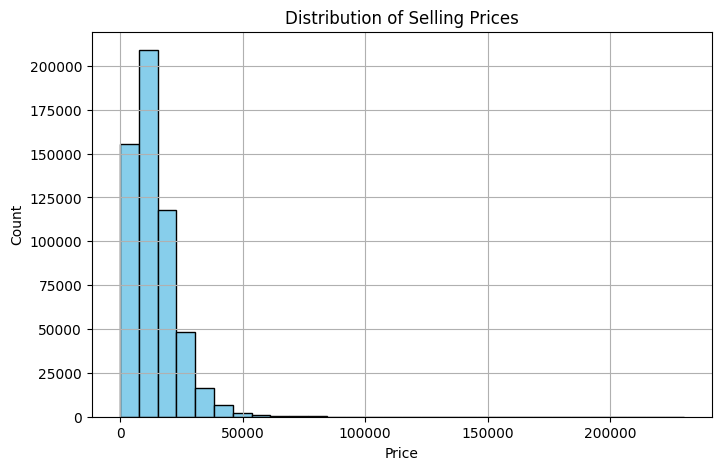

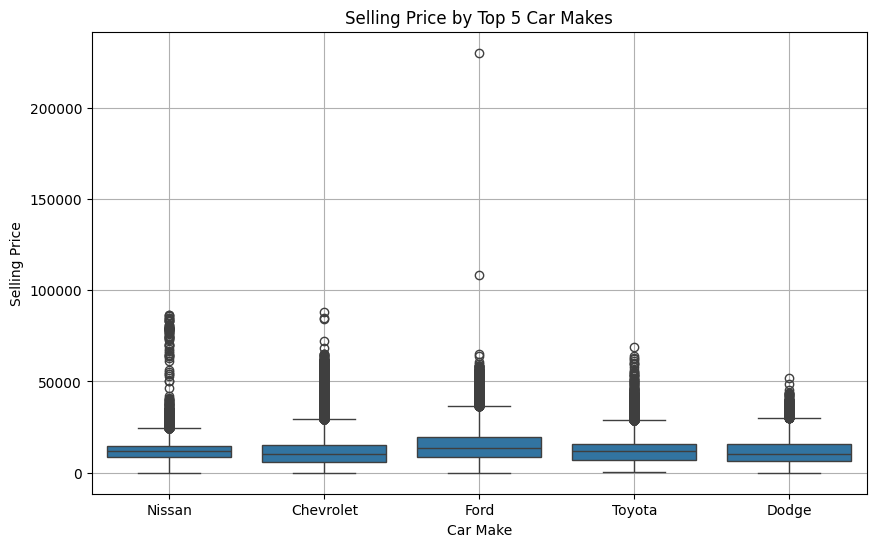

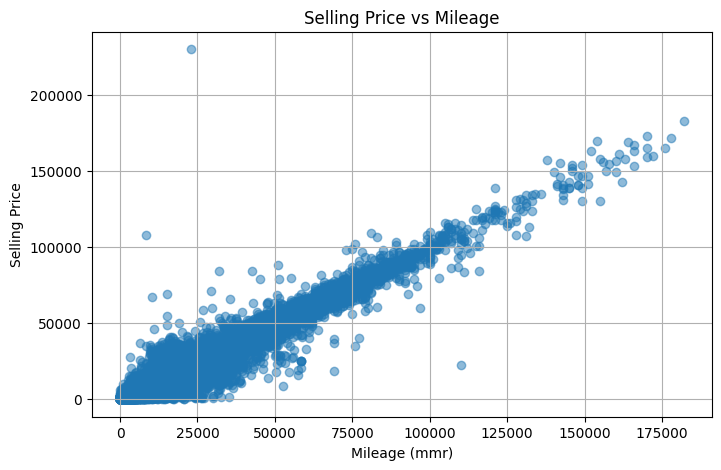

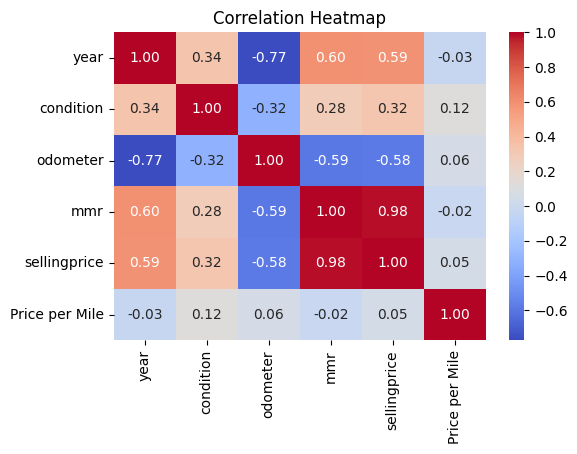

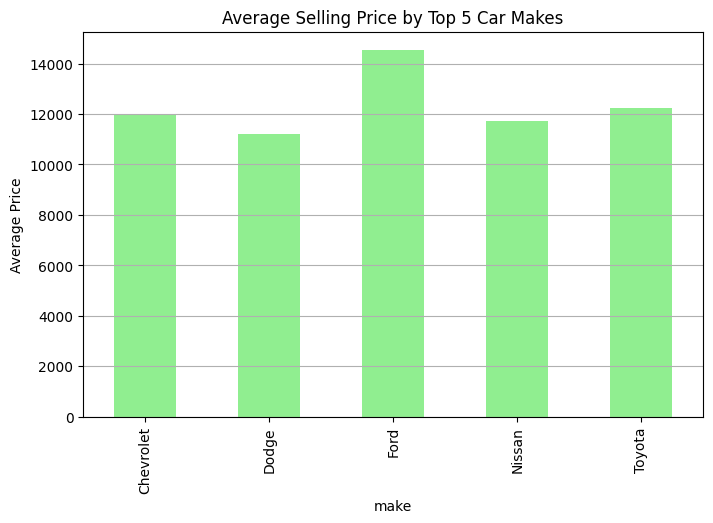

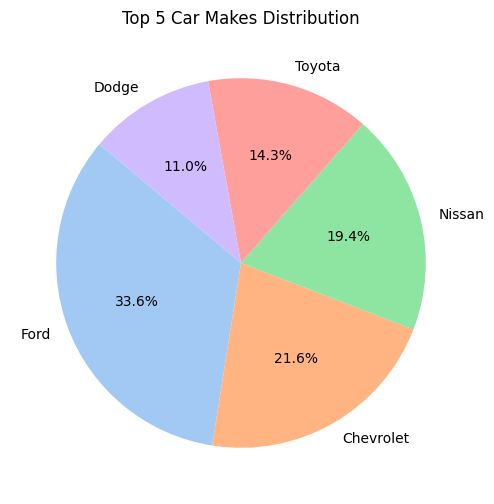

In [16]:
# --- Visualizations ---

# Histogram of selling prices
plt.figure(figsize=(8, 5))
plt.hist(df['sellingprice'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Selling Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.grid(True)
plt.show()

# Boxplot of prices by car make (top 5 makes only)
top_makes = df['make'].value_counts().nlargest(5).index
plt.figure(figsize=(10, 6))
sns.boxplot(x='make', y='sellingprice', data=df[df['make'].isin(top_makes)])
plt.title("Selling Price by Top 5 Car Makes")
plt.xlabel("Car Make")
plt.ylabel("Selling Price")
plt.grid(True)
plt.show()

# Scatter plot of price vs mileage
plt.figure(figsize=(8, 5))
plt.scatter(df['mmr'], df['sellingprice'], alpha=0.5)
plt.title("Selling Price vs Mileage")
plt.xlabel("Mileage (mmr)")
plt.ylabel("Selling Price")
plt.grid(True)
plt.show()

# Correlation heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()



# Bar chart: Average price by car make (top 5 makes)
top_makes = df['make'].value_counts().nlargest(5).index
avg_price_top_makes = df[df['make'].isin(top_makes)].groupby('make')['sellingprice'].mean()

plt.figure(figsize=(8, 5))
avg_price_top_makes.plot(kind='bar', color='lightgreen')
plt.title("Average Selling Price by Top 5 Car Makes")
plt.ylabel("Average Price")
plt.grid(axis='y')
plt.show()




# Pie chart: Distribution of car makes (top 5 only)
make_counts = df['make'].value_counts().nlargest(5)

plt.figure(figsize=(6, 6))
make_counts.plot(kind='pie', autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title("Top 5 Car Makes Distribution")
plt.ylabel("")
plt.show()
